# 🏗️ Webinar 2 – Tu Primer Modelo Completo
**Curso de Data Science & Machine Learning**  
Dataset: Online Retail (ventas de e-commerce)

---

## ¿Qué vamos a construir hoy?

| Parte | Pregunta de negocio | Tipo de modelo |
|---|---|---|
| 🔵 Parte 1 | ¿Es este cliente de *alto valor*? | **Clasificación** |
| 🟠 Parte 2 | ¿Cuánto va a gastar este cliente? | **Regresión** |

> 💡 **Regla de oro que nunca vas a olvidar:**  
> El modelo **nunca debe ver los datos de test** durante el entrenamiento.

---
## 0. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# Regresión
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('✅ Librerías cargadas')

✅ Librerías cargadas


In [4]:
# Mismo dataset que el Webinar 1
df = pd.read_excel('../Webinar 1 Teoría/online_retail.xlsx', nrows=30000)
df['TotalSpent'] = df['Quantity'] * df['UnitPrice']

clientes = df.groupby('CustomerID').agg(
    total_gastado=('TotalSpent', 'sum'),
    num_compras=('Quantity', 'count'),
    pais=('Country', 'first')
).reset_index()

mediana = clientes['total_gastado'].median()
clientes['es_alto_valor'] = np.where(clientes['total_gastado'] > mediana, 1, 0)
clientes['es_frecuente']  = np.where(clientes['num_compras'] > 10, 1, 0)

print(f'Dataset listo: {clientes.shape[0]} clientes únicos')
clientes.head()

Dataset listo: 755 clientes únicos


,CustomerID,total_gastado,num_compras,pais,es_alto_valor,es_frecuente
0,12347.0,711.79,31,Iceland,1,1
1,12370.0,1590.82,83,Cyprus,1,1
2,12386.0,258.90,8,Australia,0,0
3,12395.0,346.10,12,Belgium,1,1
4,12427.0,303.50,10,Germany,1,0


---
# 🔵 PARTE 1 — Clasificación
## Pregunta: ¿Es este cliente de alto valor?

**Target:** `es_alto_valor` → `1` si gastó más que la mediana, `0` si no.

El flujo completo que vamos a seguir:

```
[1] Definir X e y  →  [2] Split  →  [3] Fit  →  [4] Predict  →  [5] Evaluar
```

### [1] Definir X (features) e y (target)

- **X** = las columnas que el modelo *puede usar* para aprender  
- **y** = lo que queremos *predecir*

> ¿Qué columnas tiene sentido usar para saber si un cliente es de alto valor?

In [5]:
X = clientes[['num_compras', 'es_frecuente']]
y = clientes['es_alto_valor']

print('Shape de X:', X.shape)
print()
print('Distribución del target y:')
print(y.value_counts(normalize=True).round(2))

Shape de X: (755, 2)

Distribución del target y:
es_alto_valor
0    0.5
1    0.5
Name: proportion, dtype: float64


### [2] Split — separar train y test

**¿Por qué no entrenamos con todo el dataset?**  
Necesitamos un conjunto que el modelo **nunca haya visto** para saber si realmente aprendió, o solo memorizó.

```
Dataset completo
│
├── 80% → X_train, y_train  ← el modelo aprende aquí
└── 20% → X_test,  y_test   ← solo para evaluar al final
```

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% para test
    random_state=42   # fija la aleatoriedad → mismo resultado siempre
)

print(f'Train: {X_train.shape[0]} filas ({X_train.shape[0]/len(X):.0%})')
print(f'Test:  {X_test.shape[0]} filas  ({X_test.shape[0]/len(X):.0%})')

Train: 604 filas (80%)
Test:  151 filas  (20%)


### [3] Fit — el modelo aprende

Usamos **Regresión Logística**: a pesar del nombre, es un modelo de *clasificación*.  
Aprende una frontera que separa clase 0 de clase 1.

> `.fit()` es donde ocurre todo el aprendizaje. Solo usamos `X_train`.

In [7]:
modelo = LogisticRegression(random_state=42)
modelo.fit(X_train, y_train)   # ← aquí el modelo APRENDE

print('✅ Modelo entrenado')

✅ Modelo entrenado


### [4] Predict — el modelo predice

Ahora le pasamos los datos de test que **nunca vio**.  
Hay dos tipos de predicción:
- `.predict()` → clase directa: `0` o `1`
- `.predict_proba()` → probabilidad de cada clase: `[0.3, 0.7]`

> ⚠️ Predecimos tanto en **train** como en **test** para poder comparar.

In [8]:
predicciones_train = modelo.predict(X_train)
predicciones_test  = modelo.predict(X_test)

print('Primeras 5 — train:')
print('  Predicciones:', predicciones_train[:5])
print('  Reales:      ', y_train.values[:5])
print()
print('Primeras 5 — test:')
print('  Predicciones:', predicciones_test[:5])
print('  Reales:      ', y_test.values[:5])

Primeras 5 — train:
  Predicciones: [1 1 0 1 0]
  Reales:       [0 0 0 1 0]

Primeras 5 — test:
  Predicciones: [1 1 1 1 1]
  Reales:       [0 0 1 1 0]


### [5] Evaluar — ¿qué tan bien lo hizo?

#### Matriz de Confusión — entender los errores

```
                  Predijo: NO    Predijo: SÍ
Real: NO    →     TN  ✅          FP  ❌
Real: SÍ    →     FN  ❌          TP  ✅
```

Mostramos **train y test lado a lado** para detectar si hay un problema de bias o variance:
- Si **train es bueno, test es malo** → **overfitting** (alta variance)
- Si **ambos son malos** → **underfitting** (alto bias)

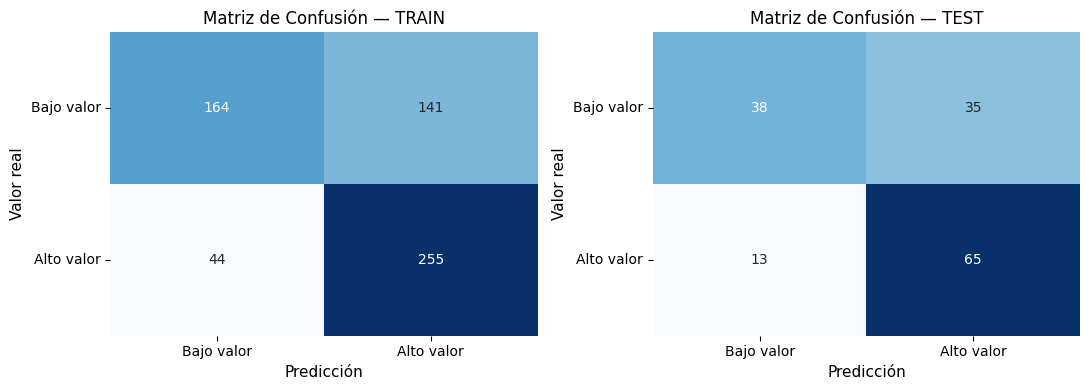

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_true, y_pred, titulo in [
    (axes[0], y_train, predicciones_train, 'Matriz de Confusión — TRAIN'),
    (axes[1], y_test,  predicciones_test,  'Matriz de Confusión — TEST'),
]:
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_xlabel('Predicción', fontsize=11)
    ax.set_ylabel('Valor real', fontsize=11)
    ax.set_title(titulo, fontsize=12)
    ax.set_xticklabels(['Bajo valor', 'Alto valor'])
    ax.set_yticklabels(['Bajo valor', 'Alto valor'], rotation=0)

plt.tight_layout()
plt.show()

#### Las 4 métricas con sklearn

| Métrica | Pregunta que responde |
|---|---|
| **Accuracy**  | ¿Qué % acerté en total? |
| **Precision** | De los que predije como SÍ, ¿cuántos eran SÍ? |
| **Recall**    | De todos los SÍ reales, ¿cuántos encontré? |
| **F1**        | Balance entre Precision y Recall |

Comparamos **train vs test** para detectar bias/variance.

In [10]:
def metricas(y_true, y_pred, nombre):
    print(f'── {nombre} ──')
    print(f'  Accuracy:  {accuracy_score(y_true, y_pred):.2%}')
    print(f'  Precision: {precision_score(y_true, y_pred):.2%}')
    print(f'  Recall:    {recall_score(y_true, y_pred):.2%}')
    print(f'  F1 Score:  {f1_score(y_true, y_pred):.2%}')
    print()

metricas(y_train, predicciones_train, 'TRAIN')
metricas(y_test,  predicciones_test,  'TEST')

── TRAIN ──
  Accuracy:  69.37%
  Precision: 64.39%
  Recall:    85.28%
  F1 Score:  73.38%

── TEST ──
  Accuracy:  68.21%
  Precision: 65.00%
  Recall:    83.33%
  F1 Score:  73.03%



#### Bonus: agregar una feature nueva y ver si mejora

¿Qué pasa si le damos al modelo el **gasto promedio por compra** como feature adicional?

In [12]:
clientes['gasto_promedio'] = clientes['total_gastado'] / clientes['num_compras']

X2 = clientes[['num_compras', 'es_frecuente', 'gasto_promedio']]
y2 = clientes['es_alto_valor']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

m2 = LogisticRegression(random_state=42)
m2.fit(X2_train, y2_train)

preds2_train = m2.predict(X2_train)
preds2_test  = m2.predict(X2_test)

print('── Modelo ORIGINAL — TEST ──')
print(classification_report(y_test, predicciones_test, target_names=['Bajo valor', 'Alto valor']))

print('── Modelo MEJORADO (+ gasto_promedio) — TEST ──')
print(classification_report(y2_test, preds2_test, target_names=['Bajo valor', 'Alto valor']))

── Modelo ORIGINAL — TEST ──
              precision    recall  f1-score   support

  Bajo valor       0.75      0.52      0.61        73
  Alto valor       0.65      0.83      0.73        78

    accuracy                           0.68       151
   macro avg       0.70      0.68      0.67       151
weighted avg       0.70      0.68      0.67       151

── Modelo MEJORADO (+ gasto_promedio) — TEST ──
              precision    recall  f1-score   support

  Bajo valor       0.86      0.74      0.79        73
  Alto valor       0.78      0.88      0.83        78

    accuracy                           0.81       151
   macro avg       0.82      0.81      0.81       151
weighted avg       0.82      0.81      0.81       151



---
# 🟠 PARTE 2 — Regresión
## Pregunta: ¿Cuánto va a gastar este cliente?

Ahora el target no es una **categoría** (0/1) sino un **número continuo**: `total_gastado`.

El flujo es **exactamente el mismo**, solo cambian:
- El modelo: `LinearRegression` en vez de `LogisticRegression`
- Las métricas: MAE, RMSE, R² en vez de precision/recall

### [1] Definir X e y

Ahora `y` es cuánto gastó el cliente — un valor numérico.

In [13]:
X_reg = clientes[['num_compras', 'es_frecuente']]
y_reg = clientes['total_gastado']

print('Shape de X:', X_reg.shape)
print()
print('Distribución del target (total_gastado):')
print(y_reg.describe().round(2))

Shape de X: (755, 2)

Distribución del target (total_gastado):
count      755.00
mean       525.16
std       1360.85
min      -1192.20
25%        156.65
50%        298.95
75%        490.18
max      27834.61
Name: total_gastado, dtype: float64


### [2] Split

In [14]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg,
    test_size=0.2,
    random_state=42
)

print(f'Train: {X_reg_train.shape[0]} filas')
print(f'Test:  {X_reg_test.shape[0]} filas')

Train: 604 filas
Test:  151 filas


### [3] Fit

In [15]:
modelo_reg = LinearRegression()
modelo_reg.fit(X_reg_train, y_reg_train)

print('✅ Modelo de regresión entrenado')
print()
print('Coeficientes aprendidos:')
for feature, coef in zip(X_reg.columns, modelo_reg.coef_):
    print(f'  {feature:>15}:  {coef:>8.2f}')
print(f'  {"intercepto":>15}:  {modelo_reg.intercept_:>8.2f}')

✅ Modelo de regresión entrenado

Coeficientes aprendidos:
      num_compras:      8.58
     es_frecuente:    218.57
       intercepto:    171.55


### [4] Predict

In [16]:
pred_reg_train = modelo_reg.predict(X_reg_train)
pred_reg_test  = modelo_reg.predict(X_reg_test)

print('Primeras 5 predicciones — TEST (€ estimados):')
print(pred_reg_test[:5].round(2))
print()
print('Valores reales — TEST:')
print(y_reg_test.values[:5].round(2))

Primeras 5 predicciones — TEST (€ estimados):
[664.64 518.8  518.8  690.37 501.64]

Valores reales — TEST:
[257.22 273.29 706.27 620.43 248.1 ]


### [5] Evaluar — métricas de regresión

En regresión no hay "acertó o falló" — medimos **qué tan lejos** estuvo la predicción.

| Métrica | Qué mide |
|---|---|
| **MAE** | Error promedio en las mismas unidades que y |
| **RMSE** | Penaliza más los errores grandes |
| **R²** | % de varianza explicada (1.0 = perfecto, 0 = inútil) |

Comparamos **train vs test** para detectar bias/variance.

In [17]:
def metricas_reg(y_true, y_pred, nombre):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'── {nombre} ──')
    print(f'  MAE:  {mae:>8.2f} €')
    print(f'  RMSE: {rmse:>8.2f} €')
    print(f'  R²:   {r2:>8.3f}   ({r2:.1%} de la varianza explicada)')
    print()

metricas_reg(y_reg_train, pred_reg_train, 'TRAIN')
metricas_reg(y_reg_test,  pred_reg_test,  'TEST')

── TRAIN ──
  MAE:    429.76 €
  RMSE:  1438.22 €
  R²:      0.058   (5.8% de la varianza explicada)

── TEST ──
  MAE:    360.26 €
  RMSE:   528.27 €
  R²:      0.396   (39.6% de la varianza explicada)



#### Visualizar: valores reales vs. predichos — Train y Test

Si el modelo fuera perfecto, **todos los puntos caerían sobre la línea roja**.  
Comparar los dos gráficos revela si hay overfitting.

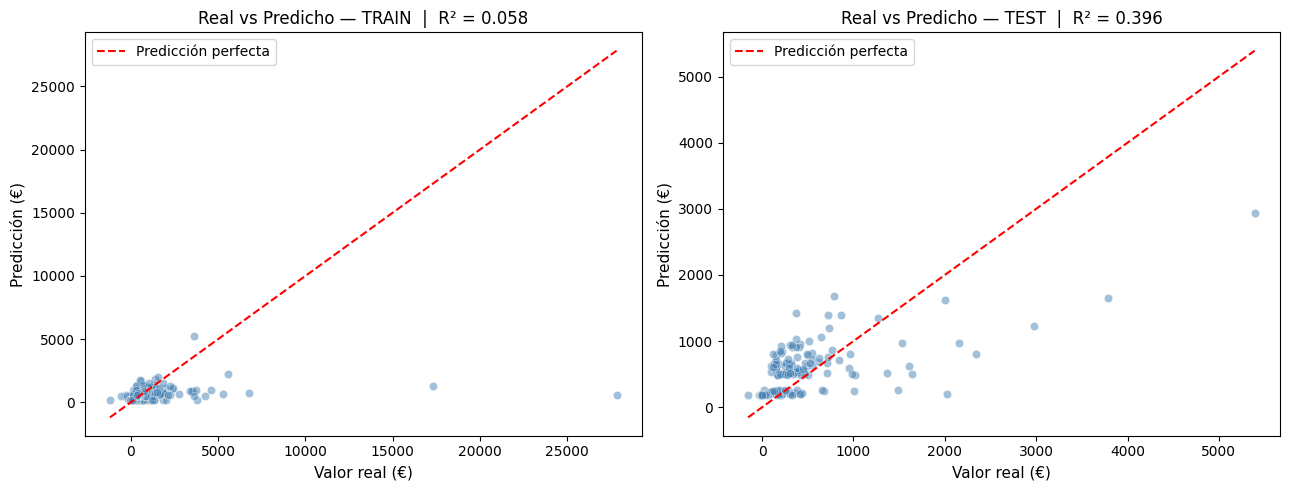

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, nombre in [
    (axes[0], y_reg_train, pred_reg_train, 'TRAIN'),
    (axes[1], y_reg_test,  pred_reg_test,  'TEST'),
]:
    r2 = r2_score(y_true, y_pred)
    ax.scatter(y_true, y_pred, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
    ax.set_xlabel('Valor real (€)', fontsize=11)
    ax.set_ylabel('Predicción (€)', fontsize=11)
    ax.set_title(f'Real vs Predicho — {nombre}  |  R² = {r2:.3f}', fontsize=12)
    ax.legend()

plt.tight_layout()
plt.show()

#### Bonus: agregar `gasto_promedio` también en regresión

¿Mejora el R² si usamos la misma feature nueva que en clasificación?

In [19]:
X_reg2 = clientes[['num_compras', 'es_frecuente', 'gasto_promedio']]
y_reg2 = clientes['total_gastado']

X_r2_train, X_r2_test, y_r2_train, y_r2_test = train_test_split(X_reg2, y_reg2, test_size=0.2, random_state=42)

m_reg2 = LinearRegression()
m_reg2.fit(X_r2_train, y_r2_train)

pred_r2_train = m_reg2.predict(X_r2_train)
pred_r2_test  = m_reg2.predict(X_r2_test)

print('── Modelo ORIGINAL ──')
metricas_reg(y_reg_train, pred_reg_train, 'Train')
metricas_reg(y_reg_test,  pred_reg_test,  'Test')

print('── Modelo MEJORADO (+ gasto_promedio) ──')
metricas_reg(y_r2_train, pred_r2_train, 'Train')
metricas_reg(y_r2_test,  pred_r2_test,  'Test')

── Modelo ORIGINAL ──
── Train ──
  MAE:    429.76 €
  RMSE:  1438.22 €
  R²:      0.058   (5.8% de la varianza explicada)

── Test ──
  MAE:    360.26 €
  RMSE:   528.27 €
  R²:      0.396   (39.6% de la varianza explicada)

── Modelo MEJORADO (+ gasto_promedio) ──
── Train ──
  MAE:    396.12 €
  RMSE:  1290.84 €
  R²:      0.241   (24.1% de la varianza explicada)

── Test ──
  MAE:    321.12 €
  RMSE:   468.83 €
  R²:      0.524   (52.4% de la varianza explicada)



---
## ✅ Resumen del Webinar 2

### El flujo es siempre el mismo
```
Datos → X e y → Split → Fit → Predict → Evaluar
```

### Lo que cambia según el tipo de problema

| | Clasificación | Regresión |
|---|---|---|
| **Target** | Categoría (0/1, A/B/C) | Número continuo |
| **Modelo** | `LogisticRegression` | `LinearRegression` |
| **Métricas** | Accuracy, Precision, Recall, F1 | MAE, RMSE, R² |
| **Primer vistazo** | `classification_report` | Gráfico Real vs Predicho |

### ¿Cómo detectar bias vs variance?

| Train | Test | Diagnóstico |
|---|---|---|
| ✅ Bueno | ✅ Bueno | Modelo correcto |
| ✅ Bueno | ❌ Malo | **Overfitting** (alta variance) |
| ❌ Malo | ❌ Malo | **Underfitting** (alto bias) |

### ¿Qué métrica usar en clasificación?

| Escenario | Métrica |
|---|---|
| FP son costosos (filtro de spam) | **Precision** |
| FN son costosos (detector de cáncer) | **Recall** |
| Ambos importan por igual | **F1 Score** |
| Dataset balanceado, costo simétrico | **Accuracy** |

---
**→ Webinar 3: más modelos (Decision Tree, Random Forest), hiperparámetros y cross-validation.**